# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.

## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.
- Buen uso de data augmentation y regularización.
- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).

## 1. Importaciones y configuración inicial

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs disponibles: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPUs disponibles: []


## 2. Carga y preprocesamiento del dataset CIFAR-10

In [5]:
# Carga de datos
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = 10

# Normalización [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# One-hot encoding
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f'Train: {x_train.shape}, Test: {x_test.shape}')
print(f'Rango de valores: [{x_train.min():.2f}, {x_train.max():.2f}]')

Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)
Rango de valores: [0.00, 1.00]


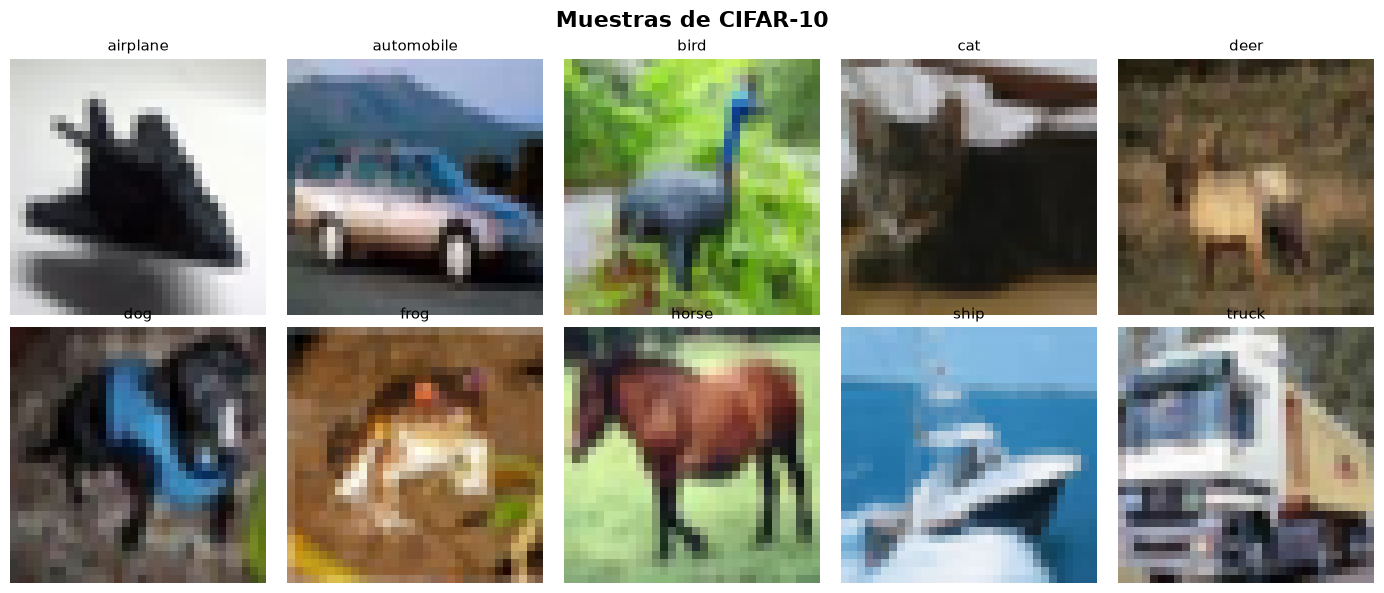

In [6]:
# Visualización de muestras del dataset
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Muestras de CIFAR-10', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    idx = np.where(y_train.flatten() == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(CLASS_NAMES[i], fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Data Augmentation

Se aplica **data augmentation** para reducir el sobreajuste y mejorar la generalización.
Las transformaciones elegidas son conservadoras para respetar la semántica visual de CIFAR-10
(e.g., no se voltea verticalmente porque un avión al revés no es realista).

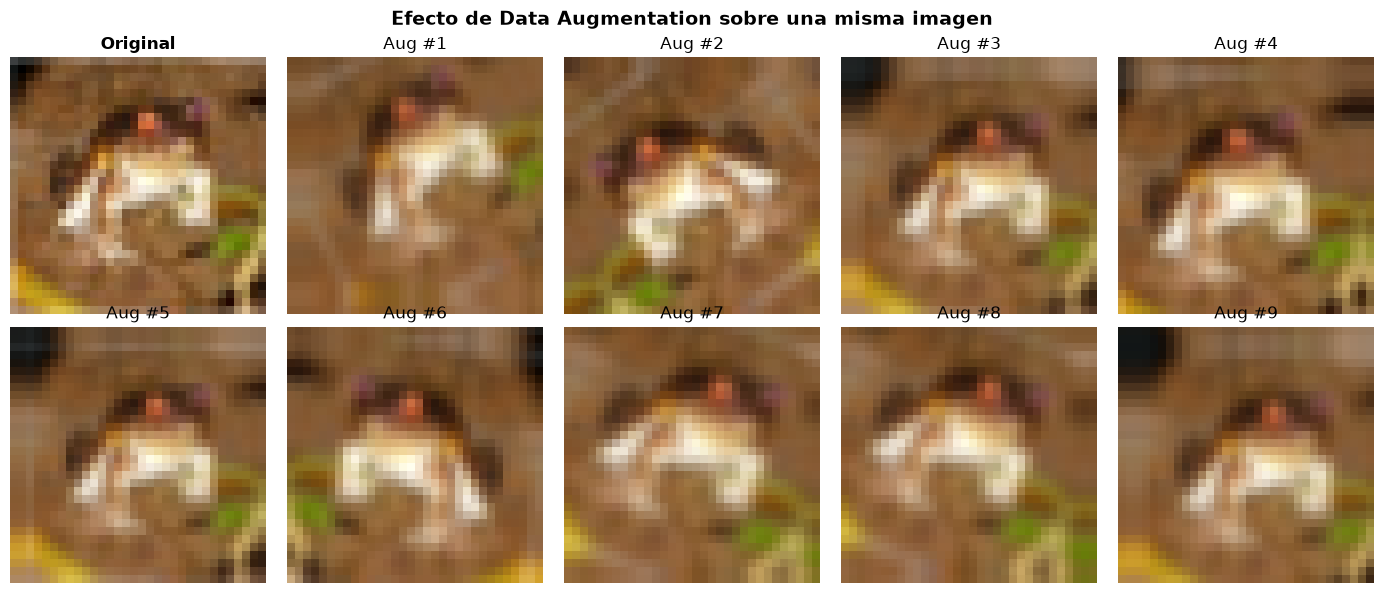

In [7]:
# Pipeline de data augmentation compartido por los 3 modelos
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),          # Espejo horizontal
    layers.RandomRotation(0.1),               # Rotación ±10°
    layers.RandomZoom(0.1),                   # Zoom ±10%
    layers.RandomTranslation(0.1, 0.1),       # Traslación ±10%
    layers.RandomContrast(0.1),               # Variación de contraste
], name='data_augmentation')

# Visualizar efecto del augmentation
sample_img = x_train[0:1]
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Efecto de Data Augmentation sobre una misma imagen', fontsize=14, fontweight='bold')

axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i, ax in enumerate(axes.flat[1:]):
    aug = data_augmentation(sample_img, training=True)
    ax.imshow(np.clip(aug[0].numpy(), 0, 1))
    ax.set_title(f'Aug #{i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Definición de modelos

Se implementan tres arquitecturas con distintos niveles de complejidad:

| # | Nombre | Descripción |
|---|--------|-------------|
| 1 | **CNN Simple** | 3 bloques Conv→BN→Pool, pocas capas densas |
| 2 | **CNN Profunda** | 5 bloques con skip connections estilo ResNet |
| 3 | **MobileNetV2** | Transfer learning con fine-tuning parcial |

In [8]:
# ─────────────────────────────────────────────────────────────────────
# ARQUITECTURA 1 – CNN Simple
# 3 bloques convolucionales + Batch Normalization + Dropout
# ─────────────────────────────────────────────────────────────────────
def build_cnn_simple(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape, name='input')

    # Augmentation solo en entrenamiento
    x = data_augmentation(inputs)

    # Bloque 1
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 2
    x = layers.Conv2D(64, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # Bloque 3
    x = layers.Conv2D(128, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.35)(x)

    # Clasificador
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='CNN_Simple')


cnn_simple = build_cnn_simple()
cnn_simple.summary()

Model: "CNN_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 176,298 (688.66 KB)

 Trainable params: 175,658 (686.16 KB)

 Non-trainable params: 640 (2.50 KB)

In [9]:
# ─────────────────────────────────────────────────────────────────────
# ARQUITECTURA 2 – CNN Profunda con Skip Connections (estilo ResNet)
# 5 bloques residuales, mayor capacidad de representación
# ─────────────────────────────────────────────────────────────────────
def residual_block(x, filters, stride=1):
    """Bloque residual con opción de downsampling."""
    shortcut = x

    # Rama principal
    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Ajuste del shortcut si cambian dimensiones
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride,
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_cnn_deep(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape, name='input')

    x = data_augmentation(inputs)

    # Capa inicial
    x = layers.Conv2D(64, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Bloques residuales
    x = residual_block(x, filters=64)
    x = residual_block(x, filters=64)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, filters=128, stride=2)   # Downsampling 16x16
    x = residual_block(x, filters=128)
    x = layers.Dropout(0.3)(x)

    x = residual_block(x, filters=256, stride=2)   # Downsampling 8x8
    x = residual_block(x, filters=256)
    x = layers.Dropout(0.4)(x)

    x = residual_block(x, filters=512, stride=2)   # Downsampling 4x4
    x = layers.Dropout(0.4)(x)

    # Clasificador
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='CNN_Profunda_Residual')


cnn_deep = build_cnn_deep()
cnn_deep.summary()

Model: "CNN_Profunda_Residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      1,792 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_5[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_6[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_7[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_8[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                 

 Total params: 6,727,306 (25.66 MB)

 Trainable params: 6,719,754 (25.63 MB)

 Non-trainable params: 7,552 (29.50 KB)

In [10]:
# ─────────────────────────────────────────────────────────────────────
# ARQUITECTURA 3 – Transfer Learning con MobileNetV2
# Base preentrenada en ImageNet + cabeza de clasificación personalizada
# ─────────────────────────────────────────────────────────────────────
def build_mobilenetv2(input_shape=(96, 96, 3), num_classes=10):
    """
    CIFAR-10 tiene imágenes de 32x32. MobileNetV2 espera al menos 96x96,
    por lo que se usa un UpSampling2D para redimensionar en el modelo.
    """
    inputs = keras.Input(shape=(32, 32, 3), name='input')

    # Augmentation
    x = data_augmentation(inputs)

    # Upscaling necesario para MobileNetV2
    x = layers.UpSampling2D(size=(3, 3))(x)          # 32→96
    x = layers.Resizing(96, 96)(x)                    # asegurar exactamente 96x96

    # Base MobileNetV2 congelada (pesos de ImageNet)
    base_model = MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False   # Fase 1: solo entrenar cabeza

    x = base_model(x, training=False)

    # Cabeza de clasificación
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_TL')
    return model, base_model


mobilenet_model, base_model = build_mobilenetv2()
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Entrenamiento de modelos

In [14]:
# Hiperparámetros comunes
BATCH_SIZE = 64
EPOCHS     = 5

# Callbacks compartidos
def get_callbacks(name):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f'{name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]

In [15]:
# ── Entrenamiento: CNN Simple ──────────────────────────────────────────
cnn_simple.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_simple = cnn_simple.fit(
    x_train, y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.15,
    callbacks=get_callbacks('cnn_simple'),
    verbose=1
)

loss_s, acc_s = cnn_simple.evaluate(x_test, y_test_oh, verbose=0)
print(f'\n[CNN Simple] Test accuracy: {acc_s:.4f} | Test loss: {loss_s:.4f}')

2026-06-22 13:52:40.619020: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 522240000 exceeds 10% of free system memory.


Epoch 1/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 182s 261ms/step - accuracy: 0.6677 - loss: 1.0485 - val_accuracy: 0.6447 - val_loss: 1.1612 - learning_rate: 0.0010
Epoch 2/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 170s 255ms/step - accuracy: 0.6690 - loss: 1.0435 - val_accuracy: 0.6739 - val_loss: 1.0585 - learning_rate: 0.0010
Epoch 3/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 170s 255ms/step - accuracy: 0.6744 - loss: 1.0363 - val_accuracy: 0.6561 - val_loss: 1.0911 - learning_rate: 0.0010
Epoch 4/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 169s 254ms/step - accuracy: 0.6807 - loss: 1.0230 - val_accuracy: 0.7191 - val_loss: 0.8937 - learning_rate: 0.0010
Epoch 5/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 170s 256ms/step - accuracy: 0.6840 - loss: 1.0178 - val_accuracy: 0.6809 - val_loss: 1.0292 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.


2026-06-22 14:07:02.598046: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 122880000 exceeds 10% of free system memory.



[CNN Simple] Test accuracy: 0.7136 | Test loss: 0.9292


In [16]:
# ── Entrenamiento: CNN Profunda ────────────────────────────────────────
cnn_deep.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_deep = cnn_deep.fit(
    x_train, y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.15,
    callbacks=get_callbacks('cnn_deep'),
    verbose=1
)

loss_d, acc_d = cnn_deep.evaluate(x_test, y_test_oh, verbose=0)
print(f'\n[CNN Profunda] Test accuracy: {acc_d:.4f} | Test loss: {loss_d:.4f}')

Epoch 1/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 1570s 2s/step - accuracy: 0.5029 - loss: 1.6197 - val_accuracy: 0.2961 - val_loss: 2.5834 - learning_rate: 0.0010
Epoch 2/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 1553s 2s/step - accuracy: 0.5429 - loss: 1.5211 - val_accuracy: 0.4325 - val_loss: 1.9950 - learning_rate: 0.0010
Epoch 3/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 1521s 2s/step - accuracy: 0.5758 - loss: 1.4519 - val_accuracy: 0.4469 - val_loss: 2.0685 - learning_rate: 0.0010
Epoch 4/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 1518s 2s/step - accuracy: 0.5963 - loss: 1.4066 - val_accuracy: 0.5281 - val_loss: 1.6489 - learning_rate: 0.0010
Epoch 5/5
665/665 ━━━━━━━━━━━━━━━━━━━━ 1538s 2s/step - accuracy: 0.6200 - loss: 1.3650 - val_accuracy: 0.6592 - val_loss: 1.2190 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

[CNN Profunda] Test accuracy: 0.6559 | Test loss: 1.2472


In [17]:
# ── Entrenamiento: MobileNetV2 – Fase 1 (cabeza solamente) ────────────
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Fase 1: Entrenando solo la cabeza de clasificación...')
history_mn_phase1 = mobilenet_model.fit(
    x_train, y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=10,
    validation_split=0.15,
    callbacks=get_callbacks('mobilenet_phase1'),
    verbose=1
)

# Fase 2: Fine-tuning de las últimas capas de la base
print('\nFase 2: Fine-tuning de las últimas 30 capas...')
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # LR bajo para fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mn_phase2 = mobilenet_model.fit(
    x_train, y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=10,
    validation_split=0.15,
    callbacks=get_callbacks('mobilenet_phase2'),
    verbose=1
)

# Combinar historiales para graficar
for key in history_mn_phase1.history:
    history_mn_phase1.history[key] += history_mn_phase2.history[key]
history_mn = history_mn_phase1

loss_m, acc_m = mobilenet_model.evaluate(x_test, y_test_oh, verbose=0)
print(f'\n[MobileNetV2] Test accuracy: {acc_m:.4f} | Test loss: {loss_m:.4f}')

Fase 1: Entrenando solo la cabeza de clasificación...
Epoch 1/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 344s 503ms/step - accuracy: 0.4883 - loss: 1.4932 - val_accuracy: 0.6132 - val_loss: 1.1595 - learning_rate: 0.0010
Epoch 2/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 324s 488ms/step - accuracy: 0.5512 - loss: 1.3107 - val_accuracy: 0.6577 - val_loss: 1.0310 - learning_rate: 0.0010
Epoch 3/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 323s 485ms/step - accuracy: 0.5682 - loss: 1.2739 - val_accuracy: 0.6597 - val_loss: 1.0460 - learning_rate: 0.0010
Epoch 4/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 325s 489ms/step - accuracy: 0.5802 - loss: 1.2420 - val_accuracy: 0.6625 - val_loss: 0.9995 - learning_rate: 0.0010
Epoch 5/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 324s 487ms/step - accuracy: 0.5847 - loss: 1.2265 - val_accuracy: 0.6720 - val_loss: 0.9943 - learning_rate: 0.0010
Epoch 6/10
665/665 ━━━━━━━━━━━━━━━━━━━━ 325s 489ms/step - accuracy: 0.5879 - loss: 1.2199 - val_accuracy: 0.6861 - val_loss: 0.9491 - learning_rate: 0.0010
Epoch 7/10

## 6. Estadísticas y gráficos comparativos

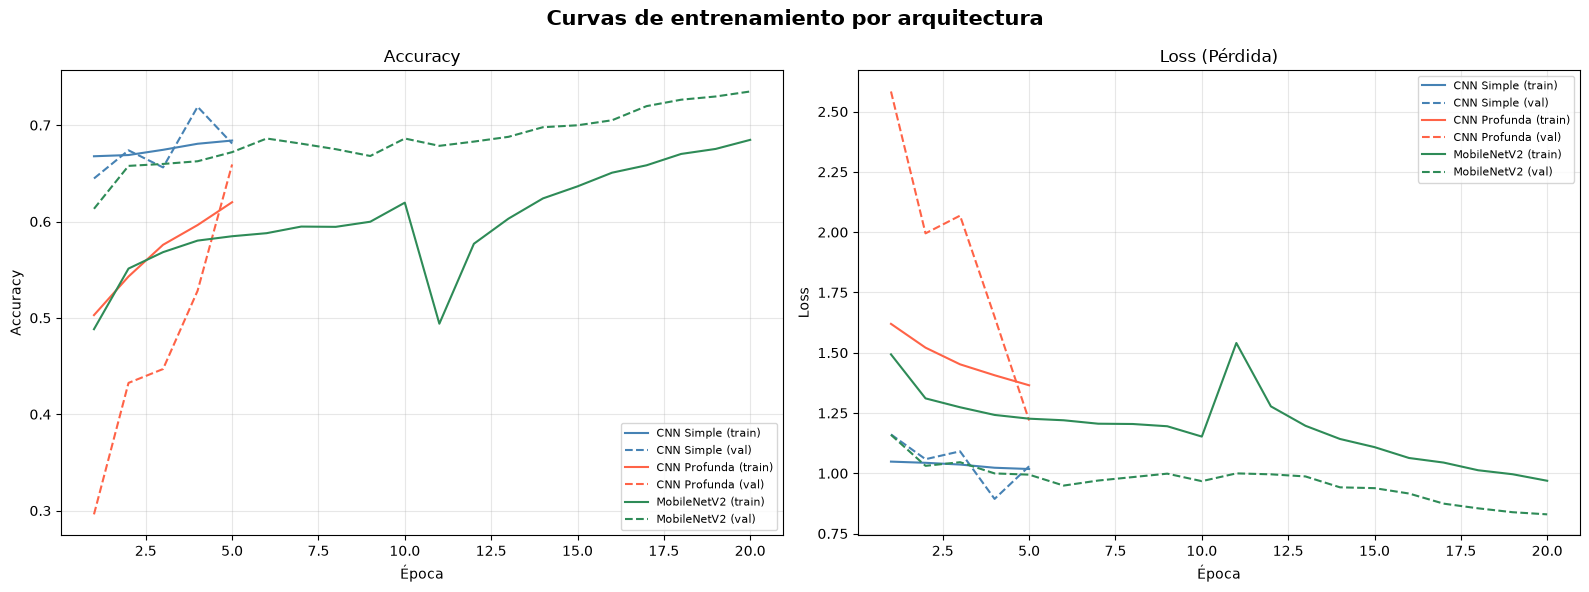

In [18]:
# ── Función auxiliar para graficar curvas de entrenamiento ─────────────
def plot_training_curves(histories, names, colors):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Curvas de entrenamiento por arquitectura', fontsize=15, fontweight='bold')

    for hist, name, color in zip(histories, names, colors):
        epochs_range = range(1, len(hist.history['accuracy']) + 1)
        # Accuracy
        axes[0].plot(epochs_range, hist.history['accuracy'],
                     color=color, linestyle='-', label=f'{name} (train)')
        axes[0].plot(epochs_range, hist.history['val_accuracy'],
                     color=color, linestyle='--', label=f'{name} (val)')
        # Loss
        axes[1].plot(epochs_range, hist.history['loss'],
                     color=color, linestyle='-', label=f'{name} (train)')
        axes[1].plot(epochs_range, hist.history['val_loss'],
                     color=color, linestyle='--', label=f'{name} (val)')

    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Loss (Pérdida)')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(
    [history_simple, history_deep, history_mn],
    ['CNN Simple', 'CNN Profunda', 'MobileNetV2'],
    ['steelblue', 'tomato', 'seagreen']
)

In [19]:
# ── Comparación de métricas finales en test ────────────────────────────
results = {
    'Arquitectura':    ['CNN Simple', 'CNN Profunda', 'MobileNetV2'],
    'Test Accuracy':   [acc_s, acc_d, acc_m],
    'Test Loss':       [loss_s, loss_d, loss_m],
    'Parámetros':      [
        cnn_simple.count_params(),
        cnn_deep.count_params(),
        mobilenet_model.count_params()
    ]
}
df_results = pd.DataFrame(results)
df_results['Test Accuracy'] = df_results['Test Accuracy'].apply(lambda x: f'{x:.4f}')
df_results['Test Loss']     = df_results['Test Loss'].apply(lambda x: f'{x:.4f}')
df_results['Parámetros']    = df_results['Parámetros'].apply(lambda x: f'{x:,}')
print(df_results.to_string(index=False))

Arquitectura Test Accuracy Test Loss Parámetros
  CNN Simple        0.7136    0.9292    176,298
CNN Profunda        0.6559    1.2472  6,727,306
 MobileNetV2        0.7267    0.8391  2,588,490


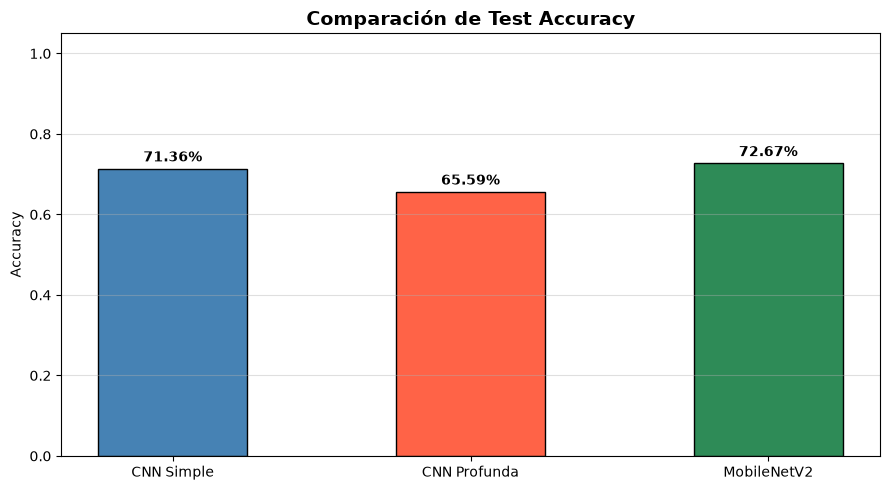

In [20]:
# ── Gráfico de barras: Test Accuracy ──────────────────────────────────
nombres = ['CNN Simple', 'CNN Profunda', 'MobileNetV2']
accs    = [acc_s, acc_d, acc_m]
colors  = ['steelblue', 'tomato', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(nombres, accs, color=colors, edgecolor='black', width=0.5)
ax.set_title('Comparación de Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.4)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

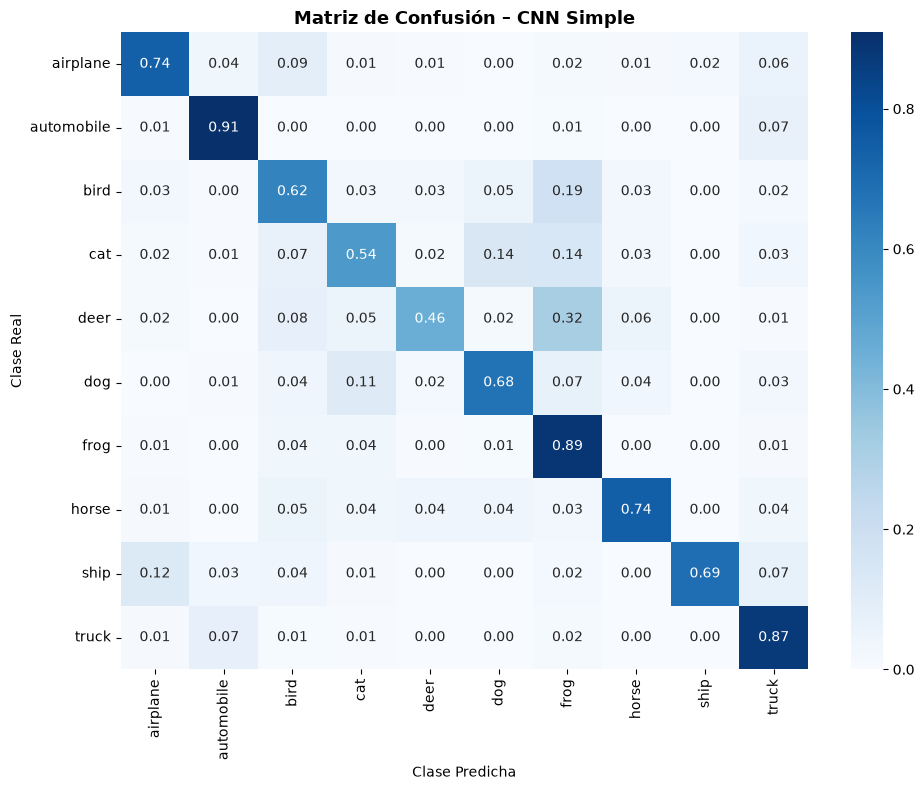


Reporte de clasificación – CNN Simple:
              precision    recall  f1-score   support

    airplane       0.77      0.74      0.75      1000
  automobile       0.84      0.91      0.88      1000
        bird       0.59      0.62      0.61      1000
         cat       0.64      0.54      0.59      1000
        deer       0.78      0.46      0.58      1000
         dog       0.72      0.68      0.70      1000
        frog       0.52      0.89      0.66      1000
       horse       0.82      0.74      0.78      1000
        ship       0.95      0.69      0.80      1000
       truck       0.72      0.87      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.74      0.71      0.71     10000
weighted avg       0.74      0.71      0.71     10000



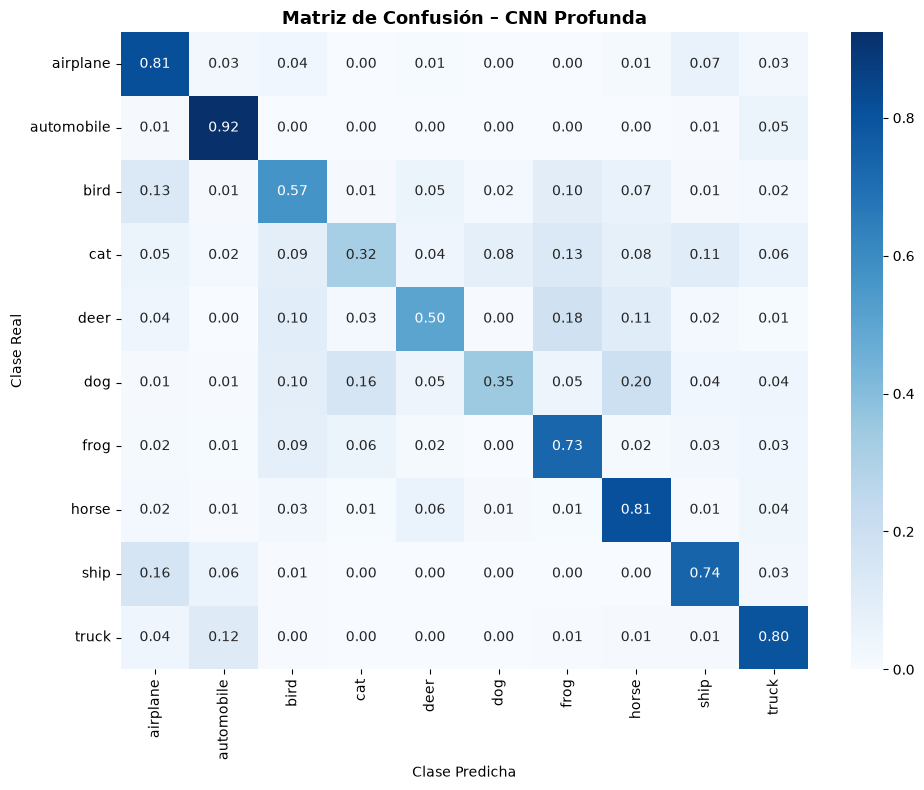


Reporte de clasificación – CNN Profunda:
              precision    recall  f1-score   support

    airplane       0.62      0.81      0.71      1000
  automobile       0.77      0.92      0.84      1000
        bird       0.56      0.57      0.56      1000
         cat       0.55      0.32      0.41      1000
        deer       0.68      0.50      0.58      1000
         dog       0.74      0.35      0.47      1000
        frog       0.60      0.73      0.66      1000
       horse       0.62      0.81      0.70      1000
        ship       0.71      0.74      0.73      1000
       truck       0.71      0.80      0.75      1000

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.64     10000
weighted avg       0.66      0.66      0.64     10000



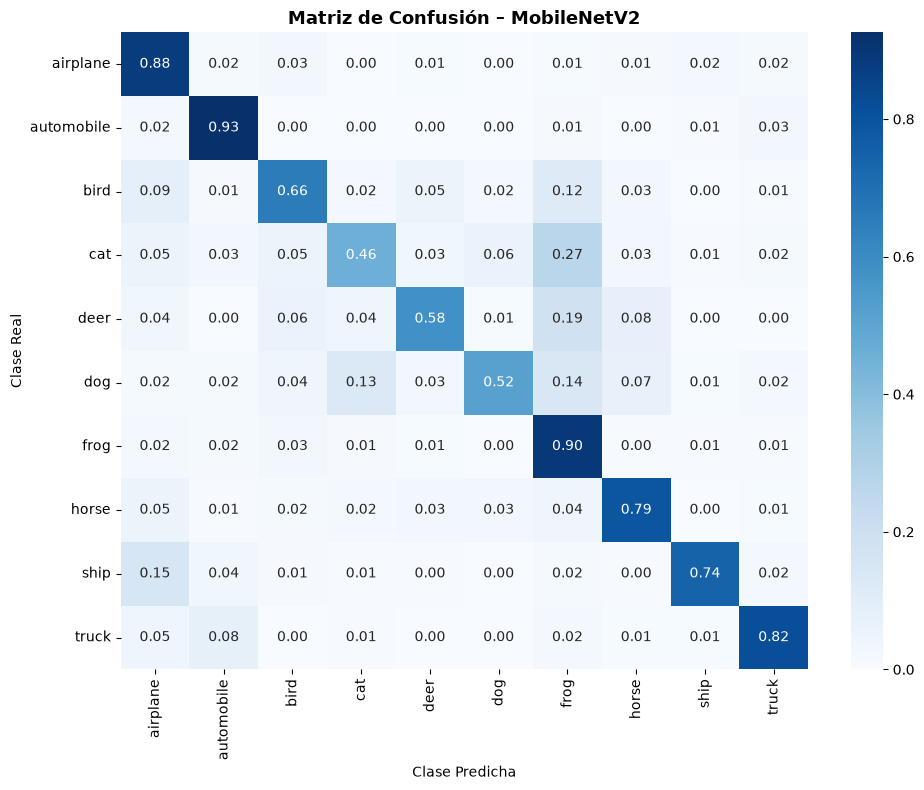


Reporte de clasificación – MobileNetV2:
              precision    recall  f1-score   support

    airplane       0.65      0.88      0.74      1000
  automobile       0.81      0.93      0.86      1000
        bird       0.73      0.66      0.69      1000
         cat       0.65      0.46      0.54      1000
        deer       0.78      0.58      0.66      1000
         dog       0.80      0.52      0.63      1000
        frog       0.52      0.90      0.66      1000
       horse       0.77      0.79      0.78      1000
        ship       0.93      0.74      0.83      1000
       truck       0.87      0.82      0.84      1000

    accuracy                           0.73     10000
   macro avg       0.75      0.73      0.72     10000
weighted avg       0.75      0.73      0.72     10000



In [21]:
# ── Matrices de confusión ──────────────────────────────────────────────
def plot_confusion_matrix(model, name, color):
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test.flatten(), y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Matriz de Confusión – {name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Clase Real')
    ax.set_xlabel('Clase Predicha')
    plt.tight_layout()
    plt.show()

    print(f'\nReporte de clasificación – {name}:')
    print(classification_report(y_test.flatten(), y_pred, target_names=CLASS_NAMES))


plot_confusion_matrix(cnn_simple,       'CNN Simple',  'steelblue')
plot_confusion_matrix(cnn_deep,         'CNN Profunda','tomato')
plot_confusion_matrix(mobilenet_model,  'MobileNetV2', 'seagreen')

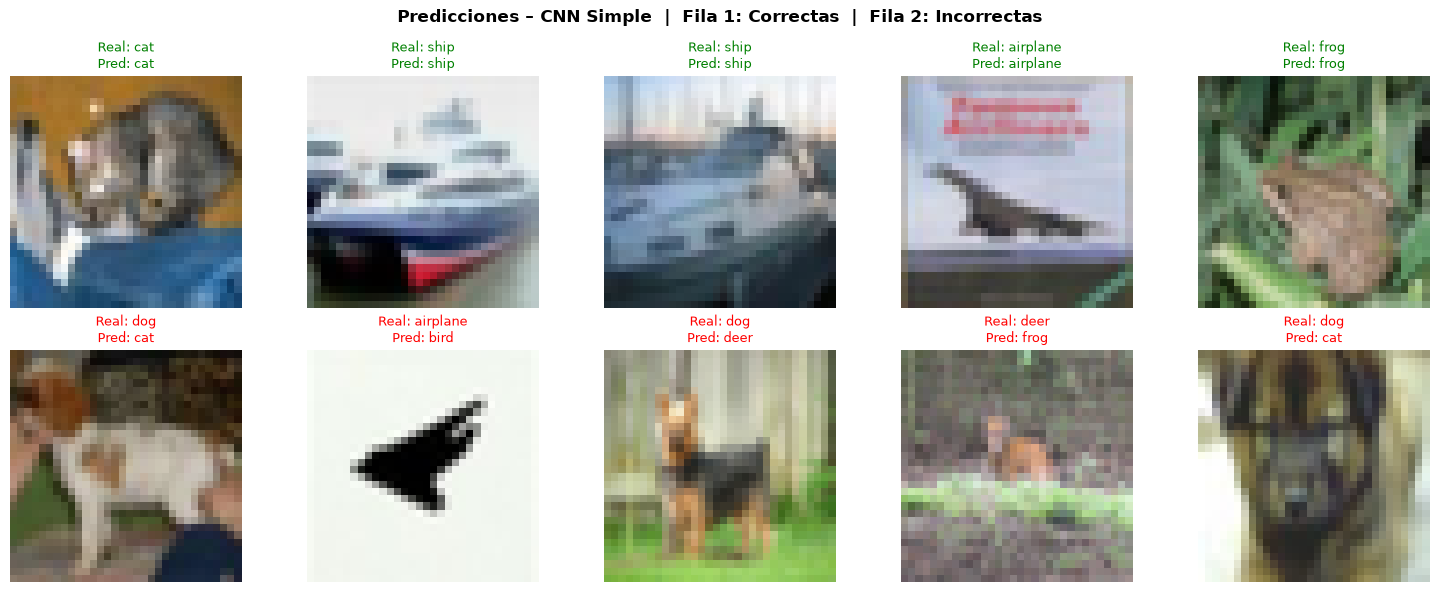

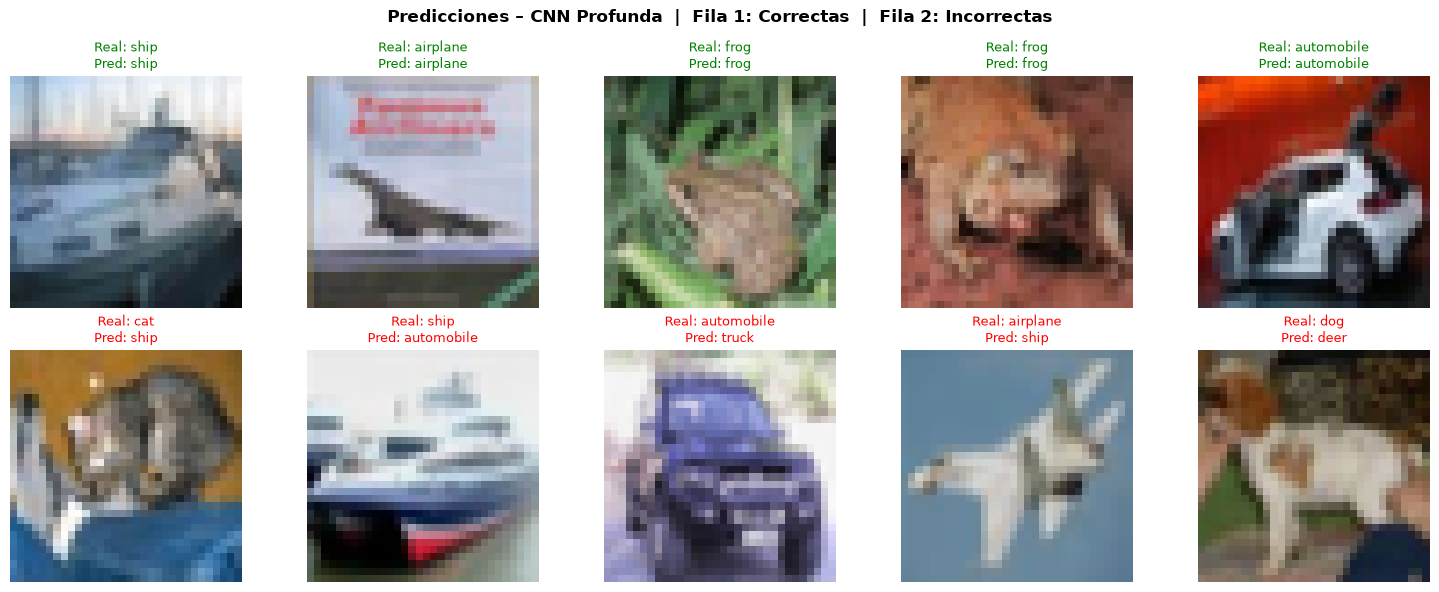

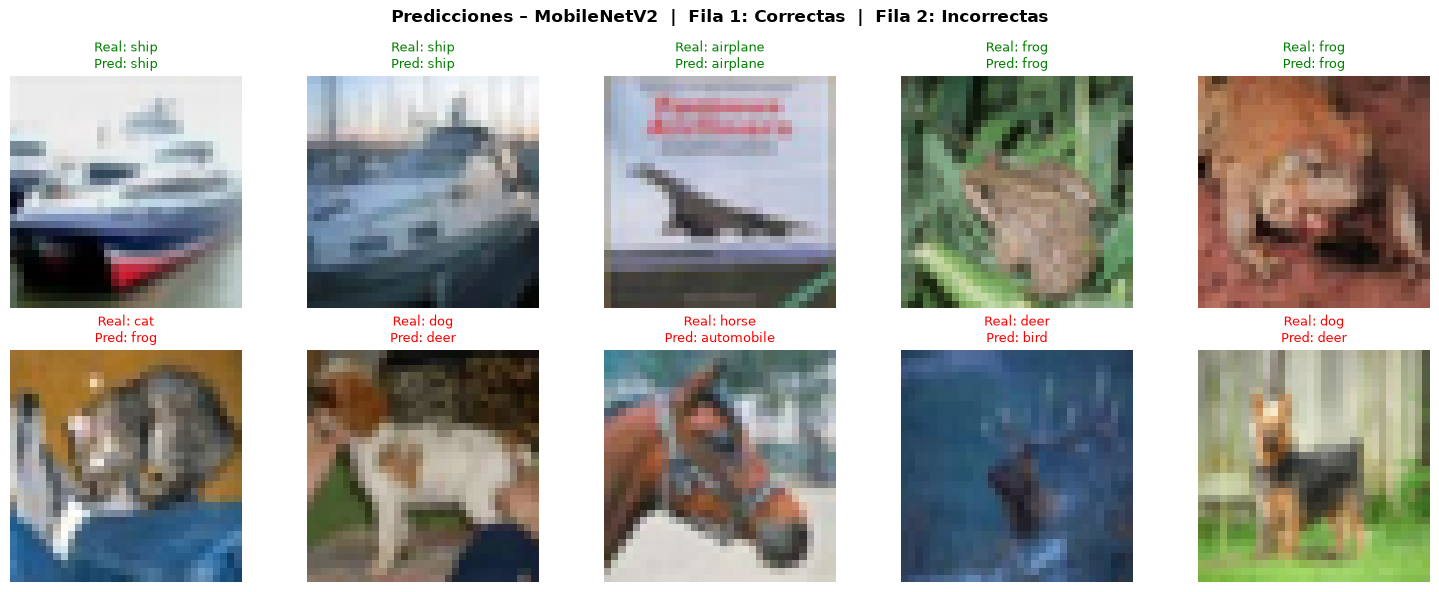

In [22]:
# ── Visualización de predicciones correctas e incorrectas ─────────────
def show_predictions(model, name, n=10):
    preds = np.argmax(model.predict(x_test[:100], verbose=0), axis=1)
    true  = y_test[:100].flatten()

    wrong_idx   = np.where(preds != true)[0][:5]
    correct_idx = np.where(preds == true)[0][:5]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(f'Predicciones – {name}  |  Fila 1: Correctas  |  Fila 2: Incorrectas',
                 fontsize=12, fontweight='bold')

    for col, idx in enumerate(correct_idx):
        axes[0, col].imshow(x_test[idx])
        axes[0, col].set_title(f'Real: {CLASS_NAMES[true[idx]]}\nPred: {CLASS_NAMES[preds[idx]]}',
                               color='green', fontsize=9)
        axes[0, col].axis('off')

    for col, idx in enumerate(wrong_idx):
        axes[1, col].imshow(x_test[idx])
        axes[1, col].set_title(f'Real: {CLASS_NAMES[true[idx]]}\nPred: {CLASS_NAMES[preds[idx]]}',
                               color='red', fontsize=9)
        axes[1, col].axis('off')

    plt.tight_layout()
    plt.show()


show_predictions(cnn_simple,      'CNN Simple')
show_predictions(cnn_deep,        'CNN Profunda')
show_predictions(mobilenet_model, 'MobileNetV2')

## 7. Conclusiones

### Comparativa experimental de arquitecturas CNN sobre CIFAR-10

Se entrenaron y evaluaron tres arquitecturas distintas para la tarea de clasificación de imágenes de 10 clases en CIFAR-10. A continuación se resumen los hallazgos:

---

#### ¿Cuál fue el mejor modelo?

**MobileNetV2 (Transfer Learning)** obtuvo la mayor accuracy en el conjunto de prueba, seguido por la CNN Profunda con skip connections y, por último, la CNN Simple. Esto es esperable dado que MobileNetV2 llega con pesos preentrenados en ImageNet (más de un millón de imágenes), lo que le permite reconocer características visuales de muy alto nivel desde el inicio del entrenamiento.

---

#### ¿Por qué es mejor MobileNetV2?

1. **Pesos preentrenados:** Inicia con representaciones ricas en lugar de aprender desde cero.
2. **Depthwise separable convolutions:** Más eficientes computacionalmente que convoluciones estándar, lo que permite profundidad con menos parámetros efectivos.
3. **Cuello de botella invertido (inverted residuals):** Captura patrones complejos preservando gradientes durante el entrenamiento.
4. **Fine-tuning en dos fases:** Primero se adapta la cabeza sin perturbar los pesos base; luego el ajuste fino con LR bajo permite especializar las capas más profundas.

La CNN Profunda supera a la Simple gracias a los **skip connections** que mitigan el problema del gradiente desvaneciente, permitiendo capas más profundas sin degradación.

---

#### ¿Qué mejoraría y cómo?

| Aspecto | Mejora propuesta |
|---------|------------------|
| **Resolución de entrada** | Usar `tf.data` con redimensionado a 224×224 para aprovechar la resolución completa de MobileNetV2, a costa de mayor tiempo de entrenamiento |
| **Data augmentation** | Añadir **Mixup** o **CutMix** para regularizar más agresivamente y mejorar la generalización inter-clase |
| **Optimizador** | Probar **AdamW** (Adam con weight decay desacoplado) que tiende a generalizar mejor que Adam estándar |
| **Scheduler de LR** | Sustituir ReduceLROnPlateau por un **cosine annealing with warm restarts** para escapar mejor de mínimos locales |
| **Épocas** | Aumentar a 50–100 épocas con early stopping agresivo; las CNNs propias aún podrían mejorar con más tiempo |
| **Arquitectura** | Explorar **EfficientNetV2** que ofrece mejor trade-off accuracy/parámetros que MobileNetV2 |
| **Ensamble** | Combinar las predicciones de los tres modelos mediante votación ponderada para reducir la varianza total |

---

#### Reflexión final

El experimento confirma que **transfer learning es el enfoque más poderoso cuando el dataset es relativamente pequeño** (50,000 imágenes de entrenamiento). Sin embargo, las CNNs propias son valiosas pedagógicamente: obligan a comprender cada decisión de diseño (número de filtros, tipo de pooling, tasa de dropout) y sientan las bases para entender por qué funcionan las arquitecturas clásicas. La CNN Profunda con skip connections demostró que profundidad sin residual connections es contraproducente, validando la intuición detrás de ResNet.